# Initial Design 

We show the simulation results of the inital GC design along 

In [22]:
import autograd.numpy as np 
import matplotlib.pyplot as plt
import autograd.numpy as anp
from autograd import value_and_grad

import tidy3d as td
import tidy3d.web as web

import pickle

from main import (make_sim, get_coupling_efficiency, apodized_to_widths,
                    R, r0, initial_fill_factor, grating_period, 
                    etch_depth, to_substrate, N_teeth, wl_range,
                    to_substrate)

This is the initial 2D design of the GC 

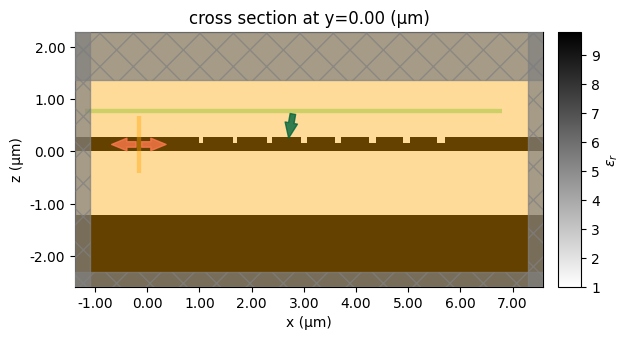

In [5]:
# get the widths of the teeth and gaps
widths = apodized_to_widths(R=R, initial_fill_factor=initial_fill_factor, N_teeth=N_teeth, grating_period=grating_period)

# make the simulation and view it
sim = make_sim(widths, r0=r0, to_substrate=to_substrate, etch_depth=etch_depth, include_field_monitor=True)

sim.plot_eps(y=0)
plt.show()

Now we run the simulation to find the initial coupling

In [9]:
sim_data = web.run(sim, task_name="GC4um_2D_test", verbose=False, path="data/tidy3d_output/tmp.hdf5")

13:50:59 EDT WARNING: Warning messages were found in the solver log. For more   
             information, check 'SimulationData.log' or use                     
             'web.download_log(task_id)'.                                       

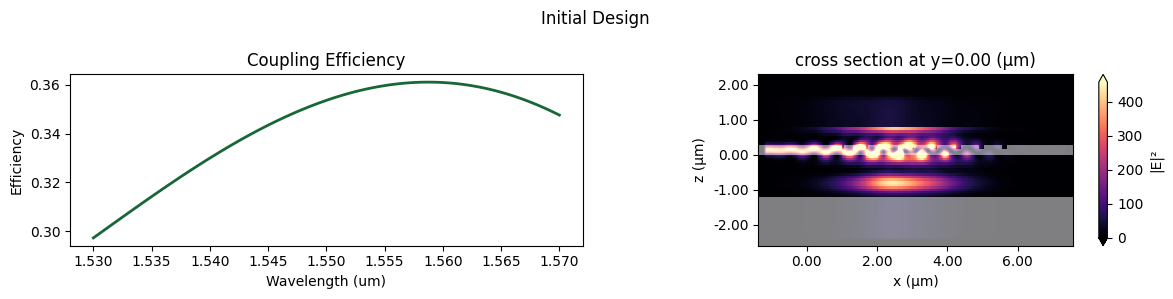

In [21]:
# compute the coupling efficiency
coupling = get_coupling_efficiency(sim_data)

# Plot the coupling efficiency and the field next to each other
fig, axs = plt.subplots(1, 2, figsize=(12, 3))
fig.suptitle("Initial Design")

# Coupling efficiency plot
axs[0].plot(wl_range, coupling, linewidth=2)
axs[0].set_title("Coupling Efficiency")
axs[0].set_xlabel("Wavelength (um)")
axs[0].set_ylabel("Efficiency")

# Field plot (show the Ez field at the center y slice)
sim_data.plot_field("field", "E", "abs^2", y=0,ax=axs[1], eps_alpha=0.5)

plt.tight_layout()
plt.show()

# Gradient Check

Now that we have a baseline for our design, we should ensure we are getting the correct gradients for the different parameters. The parameters we are going to change are: 
- the widths of the teeth and gaps 
- the distance to the first tooth
- the etch depth
- the distance to the substrate

In [ ]:
# define the objective as the average coupling efficiency across the wavelength range
def objective(params):

    # pull out the different parameters
    widths = params[:-3]
    r0 = params[-3]
    etch_depth = params[-2]
    to_substrate = params[-1]

    # make the simulation
    sim = make_sim(widths, r0=r0, to_substrate=to_substrate, etch_depth=etch_depth, include_field_monitor=False)

    # run the simulation
    sim_data = web.run(sim, task_name="GC4um_2D_test", verbose=False, path="data/tidy3d_output/tmp.hdf5")

    # compute the coupling efficiency
    coupling = get_coupling_efficiency(sim_data)

    # return the average coupling efficiency
    return anp.mean(coupling)

# make the list of our initial parameters
params0 = np.concatenate([widths, [r0], [etch_depth], [to_substrate]])

Compute the gradient using Autograd 

In [38]:
# compute the gradient of the objective using autograd
grad_objective = value_and_grad(objective)

# compute the gradient of the objective at the initial parameters
value_params0, grad_params0 = grad_objective(params0)

14:19:35 EDT WARNING: Warning messages were found in the solver log. For more   
             information, check 'SimulationData.log' or use                     
             'web.download_log(task_id)'.                                       

Compute the gradient using finite difference. We will use a batch run for this.

In [51]:
# change each parameter by 5nm
dp = .001

# make a batch run with one parameter perturbed at a time
batch_sims = {}
for i in range(len(params0)):
    params = np.array(params0, copy=True)
    params[i] += dp
    batch_sims[f"p"+str(i)] = make_sim(params[:-3], r0=params[-3], etch_depth=params[-2], to_substrate=params[-1], include_field_monitor=False)
batch = web.Batch(simulations=batch_sims,verbose=True)

# run the batch
batch_data = batch.run(path_dir="data/tidy3d_output")



Output()

14:31:56 EDT Started working on Batch containing 19 tasks.

14:32:19 EDT Maximum FlexCredit cost: 0.475 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after    
             completion.

Output()

14:33:02 EDT Batch complete.

In [53]:
#compute the gradiend using finite difference
grad_fd = np.zeros(len(params0))
for i in range(len(params0)):
    J_pert = np.mean(get_coupling_efficiency(batch_data[f"p"+str(i)]))
    grad_fd[i] = (J_pert - value_params0) / dp

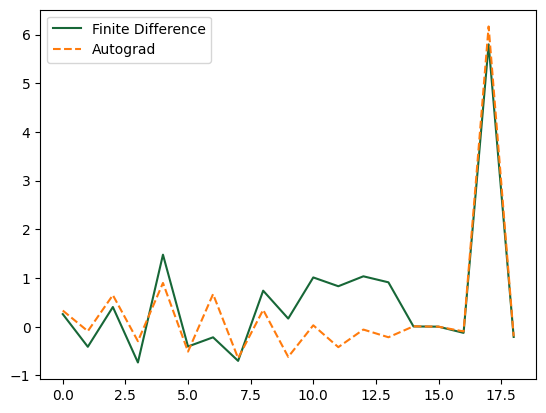

In [59]:
#compare the two gradients in a figure 
plt.plot(grad_fd, label="Finite Difference")
plt.plot(grad_params0,'--', label="Autograd")
plt.legend()
plt.show()

We see fairly consistant results between finite difference and Autograd, so we can move to inverse design.